In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import importlib

from modules import Autoencoder
importlib.reload(Autoencoder)  # 모듈 갱신

latent_dim = 32

Epoch [1/50], Loss: 0.0701
Epoch [2/50], Loss: 0.0681
Epoch [3/50], Loss: 0.0743
Epoch [4/50], Loss: 0.0690
Epoch [5/50], Loss: 0.0689
Epoch [6/50], Loss: 0.0647
Epoch [7/50], Loss: 0.0696
Epoch [8/50], Loss: 0.0735
Epoch [9/50], Loss: 0.0676
Epoch [10/50], Loss: 0.0608
Epoch [11/50], Loss: 0.0656
Epoch [12/50], Loss: 0.0646
Epoch [13/50], Loss: 0.0652
Epoch [14/50], Loss: 0.0639
Epoch [15/50], Loss: 0.0655
Epoch [16/50], Loss: 0.0648
Epoch [17/50], Loss: 0.0620
Epoch [18/50], Loss: 0.0610
Epoch [19/50], Loss: 0.0628
Epoch [20/50], Loss: 0.0671
Epoch [21/50], Loss: 0.0581
Epoch [22/50], Loss: 0.0602
Epoch [23/50], Loss: 0.0581
Epoch [24/50], Loss: 0.0686
Epoch [25/50], Loss: 0.0548
Epoch [26/50], Loss: 0.0608
Epoch [27/50], Loss: 0.0526
Epoch [28/50], Loss: 0.0540
Epoch [29/50], Loss: 0.0482
Epoch [30/50], Loss: 0.0449
Epoch [31/50], Loss: 0.0384
Epoch [32/50], Loss: 0.0311
Epoch [33/50], Loss: 0.0290
Epoch [34/50], Loss: 0.0245
Epoch [35/50], Loss: 0.0201
Epoch [36/50], Loss: 0.0212
E

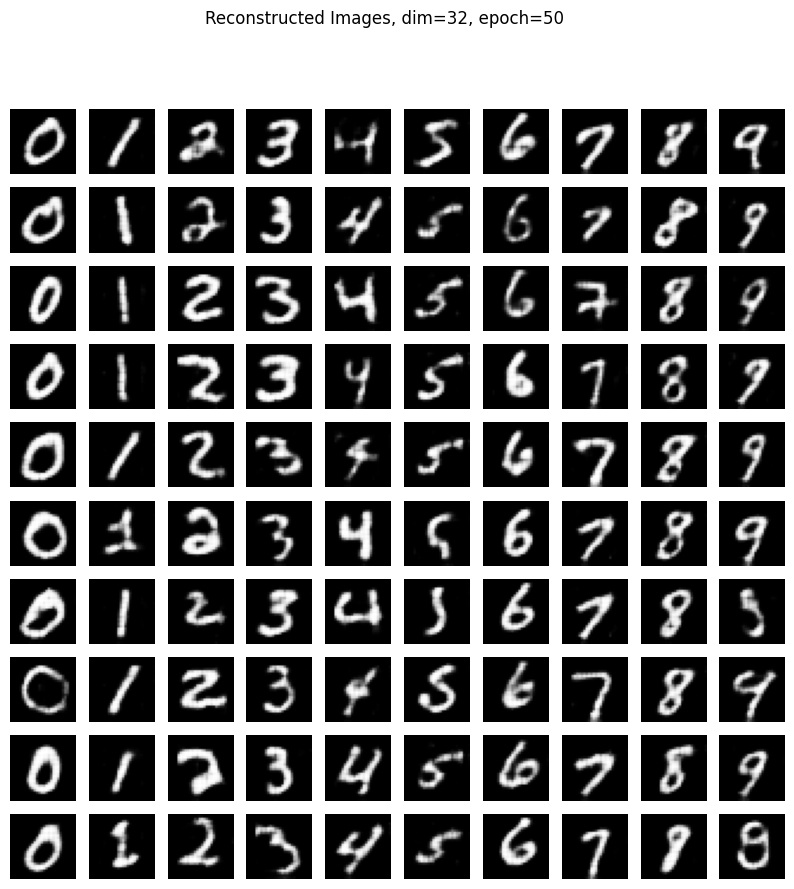

In [12]:
# 모델 초기화
autoencoder = Autoencoder.Autoencoder(latent_dim=latent_dim)
optimizer = optim.Adam(autoencoder.parameters(), lr=0.0001)
criterion = nn.MSELoss()

# 데이터 로더 설정
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

# 오토인코더 학습
epochs = 50
for epoch in range(epochs):
    for images, _ in train_loader:
        images = images.view(-1, 1, 28, 28)
        optimizer.zero_grad()
        reconstructed = autoencoder(images)
        loss = criterion(reconstructed, images)
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


# 데이터 로더 정의
transform = transforms.Compose([transforms.ToTensor()])
test_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 0~9 숫자별로 10개씩 이미지 선택
images_by_digit = {i: [] for i in range(10)}
for img, label in test_data:
    if len(images_by_digit[label]) < 10:
        images_by_digit[label].append(img)
    if all(len(images) == 10 for images in images_by_digit.values()):
        break

# 이미지 복원
reconstructed_images = []
for digit in range(10):
    images = torch.stack(images_by_digit[digit])  # 10개의 숫자 이미지
    reconstructed = autoencoder(images).detach()  # 복원된 이미지
    reconstructed_images.append(reconstructed)

# 10x10 그리드에 시각화
fig, axs = plt.subplots(10, 10, figsize=(10, 10))
for i in range(10):
    for j in range(10):
        axs[j, i].imshow(reconstructed_images[i][j].view(28, 28).numpy(), cmap='gray')
        axs[j, i].axis('off')

plt.suptitle(f"Reconstructed Images, dim={latent_dim}, epoch={epochs}")
plt.show()

In [13]:
# save & load autoencoder
save = True
load = False
if save:
    torch.save(autoencoder.state_dict(), 'savepoints/autoencoder.pth')
if load:
    autoencoder = Autoencoder.Autoencoder(latent_dim=latent_dim)
    autoencoder.load_state_dict(torch.load('savepoints/autoencoder.pth'))

In [17]:
import numpy as np
import random
import torch
from torchvision import datasets, transforms

# MNIST 데이터셋 로드
transform = transforms.Compose([transforms.ToTensor()])
test_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 클래스별로 2000개의 이미지를 랜덤하게 추출하여 저장할 딕셔너리 초기화
num_images_per_class = 500
data_dict = {}

for digit in range(10):
    # 해당 클래스의 이미지 필터링
    images_for_class = [img for img, label in test_data if label == digit]
    print("Number of images for digit", digit, ":", len(images_for_class))
    
    # 랜덤하게 2000개의 이미지 선택
    selected_images = random.sample(images_for_class, num_images_per_class)
    
    # 원본 이미지와 latent 값 저장할 리스트
    original_images = []
    latent_vectors = []
    
    # 각 이미지를 처리하여 원본 이미지와 latent 값 추출
    for img in selected_images:
        img = img.unsqueeze(0)  # 차원 맞추기 (1, 1, 28, 28)
        original_images.append(img.numpy())  # 원본 이미지 저장
        
        # 오토인코더를 통해 latent 벡터 추출
        with torch.no_grad():
            latent_vector = autoencoder.encoder(img).numpy()
            latent_vectors.append(latent_vector)

    # numpy 배열로 변환
    original_images = np.array(original_images).squeeze()  # (2000, 28, 28)
    latent_vectors = np.array(latent_vectors).squeeze()    # (2000, latent_dim)
    print(latent_vectors.shape, latent_vectors.max(), latent_vectors.min())
    
    # data_dict에 저장
    data_dict[f'{digit}_raw'] = original_images
    data_dict[f'{digit}_latent'] = latent_vectors

# 모든 데이터를 하나의 npz 파일에 저장
np.savez(f'./data/MNIST/mnist_{num_images_per_class}.npz', **data_dict)

print("Data saved successfully.")


Number of images for digit 0 : 5923
(500, 32) 0.881149 0.037495375
Number of images for digit 1 : 6742
(500, 32) 0.8889782 0.11732471
Number of images for digit 2 : 5958
(500, 32) 0.9231863 0.101996735
Number of images for digit 3 : 6131
(500, 32) 0.906761 0.064904235
Number of images for digit 4 : 5842
(500, 32) 0.9109224 0.09515497
Number of images for digit 5 : 5421
(500, 32) 0.9045321 0.06935028
Number of images for digit 6 : 5918
(500, 32) 0.91047096 0.07715086
Number of images for digit 7 : 6265
(500, 32) 0.89903307 0.07383496
Number of images for digit 8 : 5851
(500, 32) 0.9127588 0.104752064
Number of images for digit 9 : 5949
(500, 32) 0.9425599 0.06764665
Data saved successfully.


torch.Size([10, 32]) tensor(0.8527) tensor(0.1516)
torch.Size([10, 32]) tensor(0.8623) tensor(0.1531)
torch.Size([10, 32]) tensor(0.8387) tensor(0.0543)
torch.Size([10, 32]) tensor(0.8996) tensor(0.1044)
torch.Size([10, 32]) tensor(0.9175) tensor(0.1031)
torch.Size([10, 32]) tensor(0.8626) tensor(0.1308)
torch.Size([10, 32]) tensor(0.8304) tensor(0.2042)
torch.Size([10, 32]) tensor(0.8341) tensor(0.1719)
torch.Size([10, 32]) tensor(0.8105) tensor(0.1774)
torch.Size([10, 32]) tensor(0.8869) tensor(0.1747)


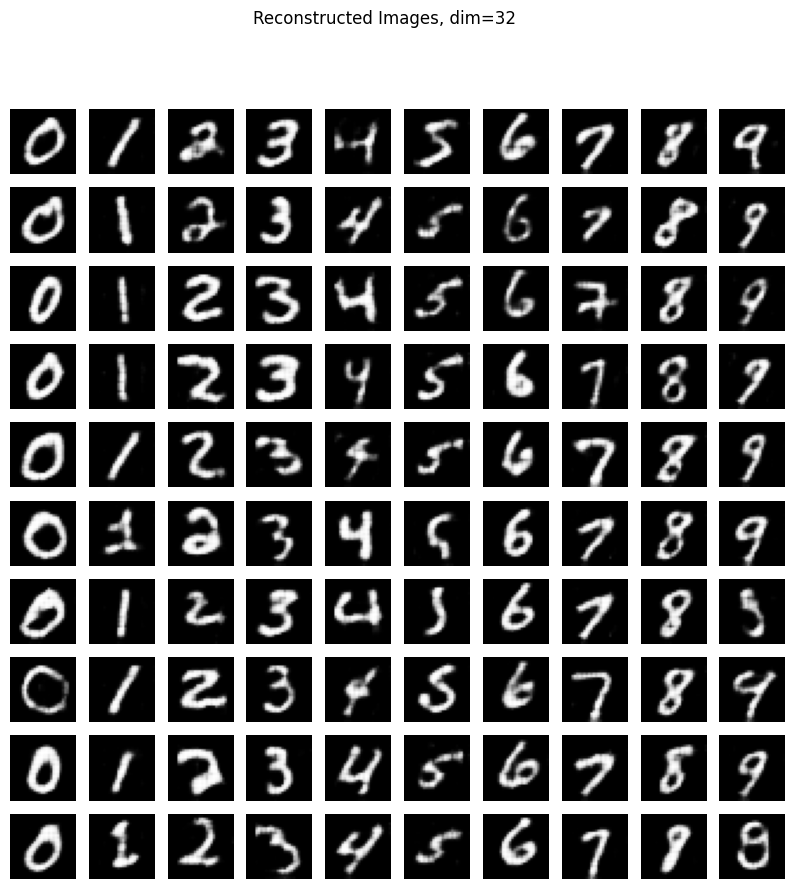

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import importlib

from modules import Autoencoder
importlib.reload(Autoencoder)  # 모듈 갱신

# 데이터 로더 정의
transform = transforms.Compose([transforms.ToTensor()])
test_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 0~9 숫자별로 10개씩 이미지 선택
images_by_digit = {i: [] for i in range(10)}
for img, label in test_data:
    if len(images_by_digit[label]) < 10:
        images_by_digit[label].append(img)
    if all(len(images) == 10 for images in images_by_digit.values()):
        break

reconstructed_images = []
for digit in range(10):
    images = torch.stack(images_by_digit[digit])  # 10개의 숫자 이미지
    
    # 이미지 -> latent 벡터
    # with torch.no_grad():
    #     reconstructed = autoencoder(images).detach()  # 인코딩

    # 압축 후 복원
    with torch.no_grad():
        latent_vectors = autoencoder.encoder(images)  # 인코딩
        reconstructed = autoencoder.decoder(latent_vectors).detach()  # 디코딩 및 detach

    print(latent_vectors.shape, latent_vectors.max(), latent_vectors.min())

    reconstructed_images.append(reconstructed)

# 10x10 그리드에 시각화
fig, axs = plt.subplots(10, 10, figsize=(10, 10))
for i in range(10):
    for j in range(10):
        axs[j, i].imshow(reconstructed_images[i][j].view(28, 28).numpy(), cmap='gray')
        axs[j, i].axis('off')

plt.suptitle(f"Reconstructed Images, dim={latent_dim}")
plt.show()